In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import sys

In [72]:
pic_path = '../local/pictures/'

_______________________________

### LCA startification

In [73]:
mirna_origin_file_path = '../MirGeneDB_miRNA_origin/hsa_mirgenedb3.0_to_everything.mirna_origin.tsv'
df_mirgenedb_mirna_origin = pd.read_csv(mirna_origin_file_path, sep='\t', header=None)
# keep only columns 8,14,15 and remove duplicates
df_mirgenedb_mirna_origin = df_mirgenedb_mirna_origin[[0, 14, 15]]
df_mirgenedb_mirna_origin = df_mirgenedb_mirna_origin.drop_duplicates()
cols = ["miRNA", "locus_node_of_origin", "family_node_of_origin"]
df_mirgenedb_mirna_origin.columns = cols
df_mirgenedb_mirna_origin

mirna_lno_dict = {}
for index, row in df_mirgenedb_mirna_origin.iterrows():
	mirna = row['miRNA']
	lno = row['family_node_of_origin']
	if mirna not in mirna_lno_dict:
		mirna_lno_dict[mirna] = []
	mirna_lno_dict[mirna].append(lno)

In [74]:
ordered_lca = {
	'Eumetazoa': 0,
	'Bilateria': 1,
	'Nephrozoa': 2,
	'Chordata': 3,
	'Olfactores': 4,
	'Vertebrata': 5,
	'Gnathostomata': 6,
	'Osteichthyes': 7,
	'Euteleostomi': 8,
	'Sarcopterygii': 9,
	'Tetrapoda': 10,
	'Amniota': 11,
	'Mammalia': 12,
	'Theria': 13,
	'Eutheria': 14,
	'Boroeutheria': 15,
	'Euarchontoglires': 16,
	'Primates': 17,
	'Simiiformes': 18,
	'Catarrhini': 19,
	'Hominidae': 20,
	'Homo_sapiens': 21
}

reverted_ordered_lca_dict = {v: k for k, v in ordered_lca.items()}
pre_2R_clades = ['Bilateria', 'Chordata', 'Eumetazoa', 'Vertebrata', 'Nephrozoa', 'Olphactores']

In [75]:
def add_ensembl_lca(df, dict):
    df_cp = df.copy()
    df_cp['lca'] = df_cp.apply(lambda row: dict.get((row['miRNA_1'], row['miRNA_2'])), axis=1)
    return df_cp

def add_mirgenedb_lca(df, single_miRNA_dict, reverted_lca_dict):
	df_cp = df.copy()
	def compute_max_lca(miRNA):
		# If the miRNA value itself is NaN/null, skip immediately
		if pd.isna(miRNA):
			return -1
		# Look up its list of lno’s; if that’s not a list/tuple, treat as empty
		lno_list = single_miRNA_dict.get(miRNA, [])
		if not isinstance(lno_list, (list, tuple)):
			return -1
		# Map to ordered_lca values and take the max (or -1 if empty)
		return max((ordered_lca.get(lno, -1) for lno in lno_list), default=-1)

	df_cp['lca_1']    = df_cp['miRNA_1'].apply(compute_max_lca)
	df_cp['lca_2']    = df_cp['miRNA_2'].apply(compute_max_lca)
	df_cp['lca_code']= df_cp[['lca_1','lca_2']].max(axis=1)
	df_cp = df_cp.drop(columns=['lca_1','lca_2'])

    # **just use the dict you passed in**
	df_cp['lca'] = df_cp['lca_code'].apply(
		lambda code: reverted_lca_dict.get(code, 'Unknown')
	)
	return df_cp

In [76]:
source = 'mgdb_3.0'	# "mgdb_3.0" or "ensembl"
file_path = f'./nw.hsa_{source}_premirna.WGD_flag.intragenic_flag.7mer.s5.tsv'

df = pd.read_csv(file_path, sep='\t', header=None)
cols = ['miRNA_1', 'miRNA_2', 'seqsim_score', 'miRNA_duplication_flag', 'Host_genes_duplication_flag']
df.columns = cols

df =add_mirgenedb_lca(df, mirna_lno_dict, reverted_ordered_lca_dict)
df

,miRNA_1,miRNA_2,seqsim_score,miRNA_duplication_flag,Host_genes_duplication_flag,lca_code,lca
0,Hsa-Mir-33-P1,Hsa-Mir-33-P3,45.0,WGD,WGD_intragenic,1,Bilateria
1,Hsa-Mir-26-P2,Hsa-Mir-26-P4,46.0,WGD,WGD_intragenic,5,Vertebrata
2,Hsa-Mir-26-P1,Hsa-Mir-26-P4,50.0,WGD,WGD_intragenic,5,Vertebrata
3,Hsa-Mir-26-P1,Hsa-Mir-26-P2,46.0,WGD,WGD_intragenic,5,Vertebrata
4,Hsa-Mir-218-P2,Hsa-Mir-218-P4,49.0,WGD,WGD_intragenic,5,Vertebrata
...,...,...,...,...,...,...,...
2462,Hsa-Let-7-P1b,Hsa-Let-7-P2b2,44.0,SSD,NaN,1,Bilateria
2463,Hsa-Let-7-P1b,Hsa-Let-7-P2b1,46.0,SSD,NaN,1,Bilateria
2464,Hsa-Let-7-P1b,Hsa-Let-7-P2a3,46.0,SSD,NaN,1,Bilateria
2465,Hsa-Let-7-P1b,Hsa-Let-7-P2a2,48.0,SSD,NaN,1,Bilateria


In [77]:
wgd_intragenic_count = df[df['Host_genes_duplication_flag'] == 'WGD_intragenic'].shape[0]
print(f'Number of intragenic WGD pairs: {wgd_intragenic_count}')
wgd_count = df[df['miRNA_duplication_flag'] == 'WGD'].shape[0]
print(f'Number of general WGD pairs: {wgd_count}')

Number of intragenic WGD pairs: 12
Number of general WGD pairs: 102


In [78]:
pairs_to_relabel = [
	['Hsa-Mir-199-P1-v1', 'Hsa-Mir-199-P2-v1'],
	['Hsa-Mir-199-P1-v1', 'Hsa-Mir-199-P3-v1'],
	['Hsa-Mir-199-P2-v1', 'Hsa-Mir-199-P3-v1'],
	['Hsa-Mir-196-P3', 'Hsa-Mir-196-P4'],       # AKA MIR196-A1 MIR196-A2
	['Hsa-Mir-10-P1c-v1', 'Hsa-Mir-10-P1b-v1'], # AKA MIR10-A MIR10-B
]

for pair in pairs_to_relabel:
	condition = ((df['miRNA_1'] == pair[0]) & (df['miRNA_2'] == pair[1]) | (df['miRNA_1'] == pair[1]) & (df['miRNA_2'] == pair[0]))
	df.loc[condition & (df['miRNA_duplication_flag'] == 'WGD'), 'Host_genes_duplication_flag'] = 'WGD_intragenic'

	df.loc[condition & (df['miRNA_duplication_flag'] == 'SSD'), 'Host_genes_duplication_flag'] = 'WGD_intragenic'
	df.loc[condition & (df['miRNA_duplication_flag'] == 'SSD'), 'miRNA_duplication_flag'] = 'WGD'

df[df['Host_genes_duplication_flag'] == 'WGD_intragenic']

,miRNA_1,miRNA_2,seqsim_score,miRNA_duplication_flag,Host_genes_duplication_flag,lca_code,lca
0,Hsa-Mir-33-P1,Hsa-Mir-33-P3,45.0,WGD,WGD_intragenic,1,Bilateria
1,Hsa-Mir-26-P2,Hsa-Mir-26-P4,46.0,WGD,WGD_intragenic,5,Vertebrata
2,Hsa-Mir-26-P1,Hsa-Mir-26-P4,50.0,WGD,WGD_intragenic,5,Vertebrata
3,Hsa-Mir-26-P1,Hsa-Mir-26-P2,46.0,WGD,WGD_intragenic,5,Vertebrata
4,Hsa-Mir-218-P2,Hsa-Mir-218-P4,49.0,WGD,WGD_intragenic,5,Vertebrata
5,Hsa-Mir-204-P1,Hsa-Mir-204-P2,46.0,WGD,WGD_intragenic,5,Vertebrata
6,Hsa-Mir-153-P1,Hsa-Mir-153-P2,50.0,WGD,WGD_intragenic,1,Bilateria
7,Hsa-Mir-148-P3,Hsa-Mir-148-P4,40.0,WGD,WGD_intragenic,5,Vertebrata
8,Hsa-Mir-128-P1,Hsa-Mir-128-P2,49.0,WGD,WGD_intragenic,5,Vertebrata
9,Hsa-Mir-103-P2,Hsa-Mir-103-P4,51.0,WGD,WGD_intragenic,1,Bilateria


In [79]:
df_preverterata = df.copy()
df_preverterata = df_preverterata[~df_preverterata['lca'].isin(pre_2R_clades)]


In [80]:
df_wgd = df[df['miRNA_duplication_flag'] == 'WGD']
df_wgd_intragenic = df_wgd[df_wgd['Host_genes_duplication_flag'] == 'WGD_intragenic']
df_ssd = df[df['miRNA_duplication_flag'] == 'SSD']

df_postvertebrata_wgd = df_preverterata[df_preverterata['miRNA_duplication_flag'] == 'WGD']
df_postvertebrata_wgd_intragenic = df_postvertebrata_wgd[df_postvertebrata_wgd['Host_genes_duplication_flag'] == 'WGD_intragenic']
df_postvertebrata_ssd = df_preverterata[df_preverterata['miRNA_duplication_flag'] == 'SSD']

In [81]:
df_wgd_scores = df_wgd['seqsim_score'].astype(int)
df_ssd_scores = df_ssd['seqsim_score'].astype(int)
df_wgd_intragenic_scores = df_wgd_intragenic['seqsim_score'].astype(int)

df_postvertebrata_wgd_scores = df_postvertebrata_wgd['seqsim_score'].astype(int)
df_postvertebrata_ssd_scores = df_postvertebrata_ssd['seqsim_score'].astype(int)
df_postvertebrata_wgd_intragenic_scores = df_postvertebrata_wgd_intragenic['seqsim_score'].astype(int)

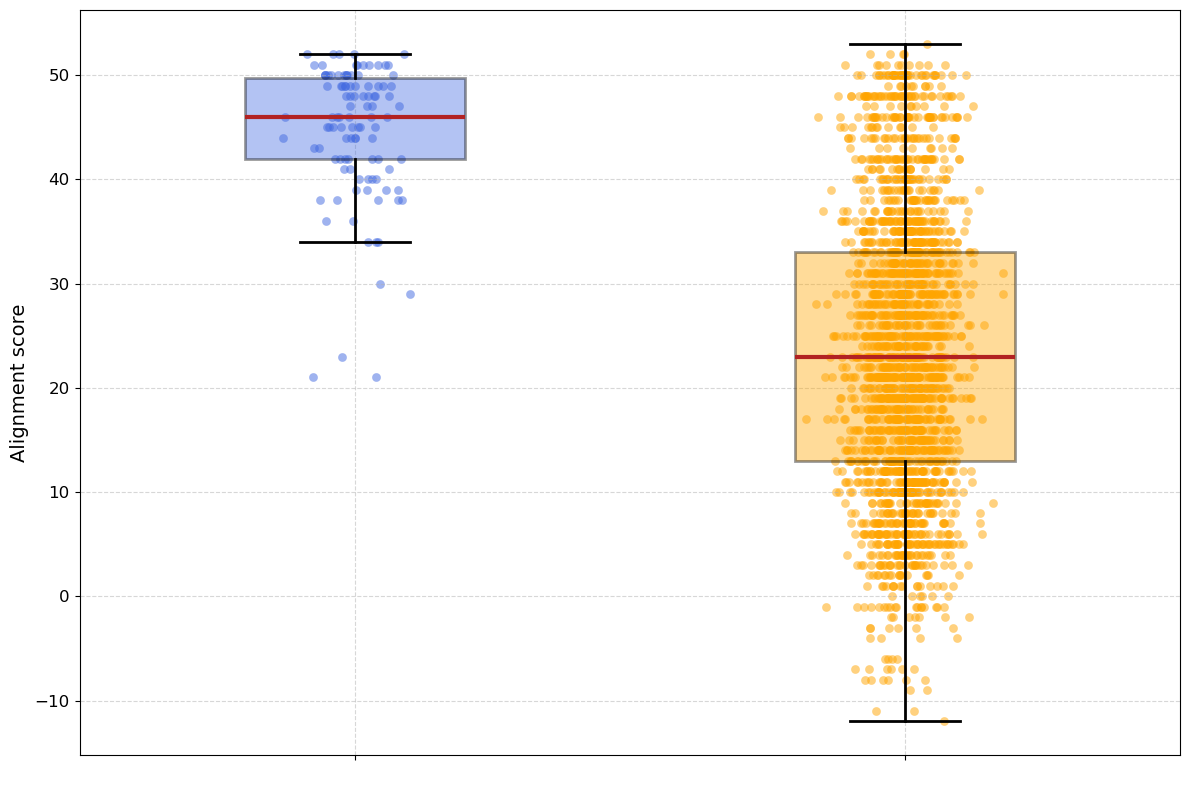

In [82]:
data = [df_wgd_scores, df_ssd_scores]
positions = [0, 1]
colors = ['royalblue', 'orange']

plt.figure(figsize=(12, 8))

box = plt.boxplot(data, 
                  positions=positions, 
                  widths=0.4,
				  #notch=True,
                  patch_artist=True, 
                  showfliers=False)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(2)
    patch.set_alpha(0.4)
    
for element in ['whiskers', 'caps']:
    for line in box[element]:
        line.set_linewidth(2)
        line.set_color('black')
        
for element in ['medians']:
    for line in box[element]:
        line.set_linewidth(3)
        line.set_color('firebrick')

for i, (scores, color) in enumerate(zip(data, colors)):
    jittered_x = np.random.normal(loc=positions[i], scale=0.05, size=len(scores))
    plt.scatter(jittered_x, scores, alpha=0.5, color=color, linewidth=0.2, label=['WGD', 'SSD'][i])

plt.ylabel('Alignment score', fontsize=14)
plt.xticks(positions, [' ', ' '], fontsize=100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
#plt.savefig(f'{pic_path}true_duplicates_ensemblSSD_sequence_similarity_boxplot.png', dpi=300)
plt.show()

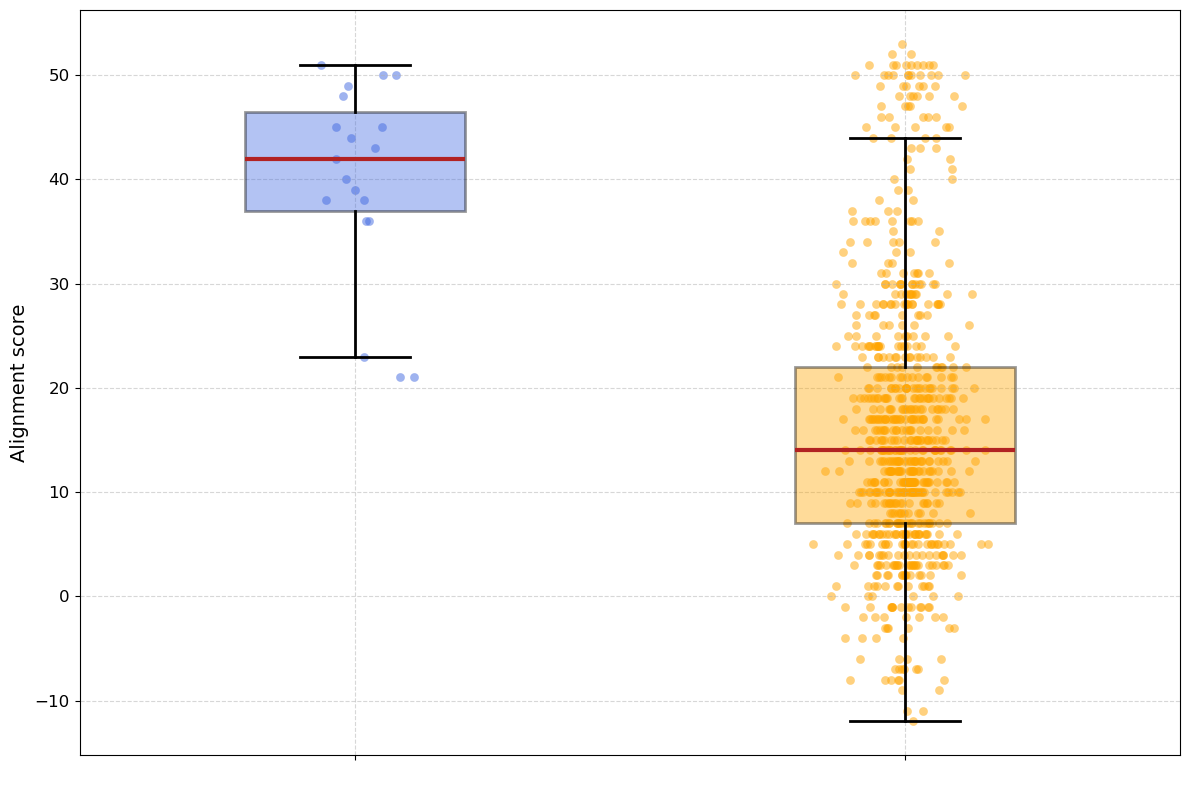

In [83]:
data_postvertebrata = [df_postvertebrata_wgd_scores, df_postvertebrata_ssd_scores]
positions = [0, 1]
colors = ['royalblue', 'orange']

plt.figure(figsize=(12, 8))

box = plt.boxplot(data_postvertebrata, 
                  positions=positions, 
                  widths=0.4,
				  #notch=True,
                  patch_artist=True, 
                  showfliers=False)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(2)
    patch.set_alpha(0.4)
    
for element in ['whiskers', 'caps']:
    for line in box[element]:
        line.set_linewidth(2)
        line.set_color('black')
        
for element in ['medians']:
    for line in box[element]:
        line.set_linewidth(3)
        line.set_color('firebrick')

for i, (scores, color) in enumerate(zip(data_postvertebrata, colors)):
    jittered_x = np.random.normal(loc=positions[i], scale=0.05, size=len(scores))
    plt.scatter(jittered_x, scores, alpha=0.5, color=color, linewidth=0.2, label=['WGD', 'SSD'][i])

plt.ylabel('Alignment score', fontsize=14)
plt.xticks(positions, [' ', ' '], fontsize=100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.savefig(f'{pic_path}true_duplicates_mirgenedSSD_postvertebrata_sequence_similarity_boxplot.png', dpi=300)
plt.show()

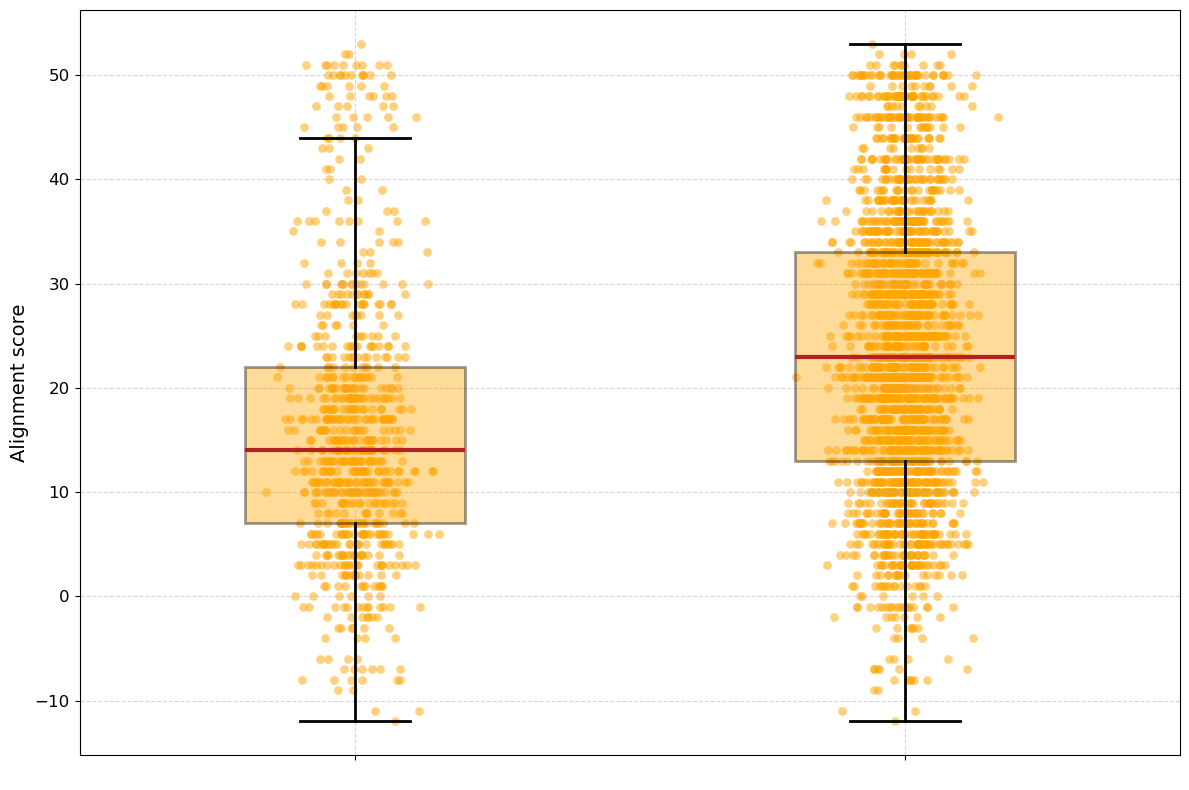

In [84]:
data_ssd_postvertebrata = [df_postvertebrata_ssd_scores, df_ssd_scores]
positions = [0, 1]
colors = ['orange', 'orange']

plt.figure(figsize=(12, 8))

box = plt.boxplot(data_ssd_postvertebrata, 
                  positions=positions, 
                  widths=0.4,
				  #notch=True,
                  patch_artist=True, 
                  showfliers=False)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')
    patch.set_linewidth(2)
    patch.set_alpha(0.4)
    
for element in ['whiskers', 'caps']:
    for line in box[element]:
        line.set_linewidth(2)
        line.set_color('black')
        
for element in ['medians']:
    for line in box[element]:
        line.set_linewidth(3)
        line.set_color('firebrick')

for i, (scores, color) in enumerate(zip(data_ssd_postvertebrata, colors)):
    jittered_x = np.random.normal(loc=positions[i], scale=0.05, size=len(scores))
    plt.scatter(jittered_x, scores, alpha=0.5, color=color, linewidth=0.2, label=['SSD_Postvertebrata', 'SSD'][i])

plt.ylabel('Alignment score', fontsize=14)
plt.xticks(positions, [' ', ' '], fontsize=100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.savefig(f'{pic_path}true_duplicates_mirgenedbSSD_postvertebrata_sequence_similarity_boxplot.png', dpi=300)
plt.show()

In [67]:
ks_statistic, p_value = stats.ks_2samp(data[0], data[1])
print(f'Kolmogorov-Smirnov test statistic: {ks_statistic}, p-value: {p_value}', file=sys.stderr)

Kolmogorov-Smirnov test statistic: 0.7531826136990243, p-value: 1.5005129365439863e-59


In [85]:
ks_statistic_ssd_postvert, p_value_ssd_postvert = stats.ks_2samp(data_ssd_postvertebrata[0], data_ssd_postvertebrata[1])
print(f'Kolmogorov-Smirnov test statistic: {ks_statistic_ssd_postvert}, p-value: {p_value_ssd_postvert}', file=sys.stderr)

Kolmogorov-Smirnov test statistic: 0.2828696306733596, p-value: 5.675543015562002e-43


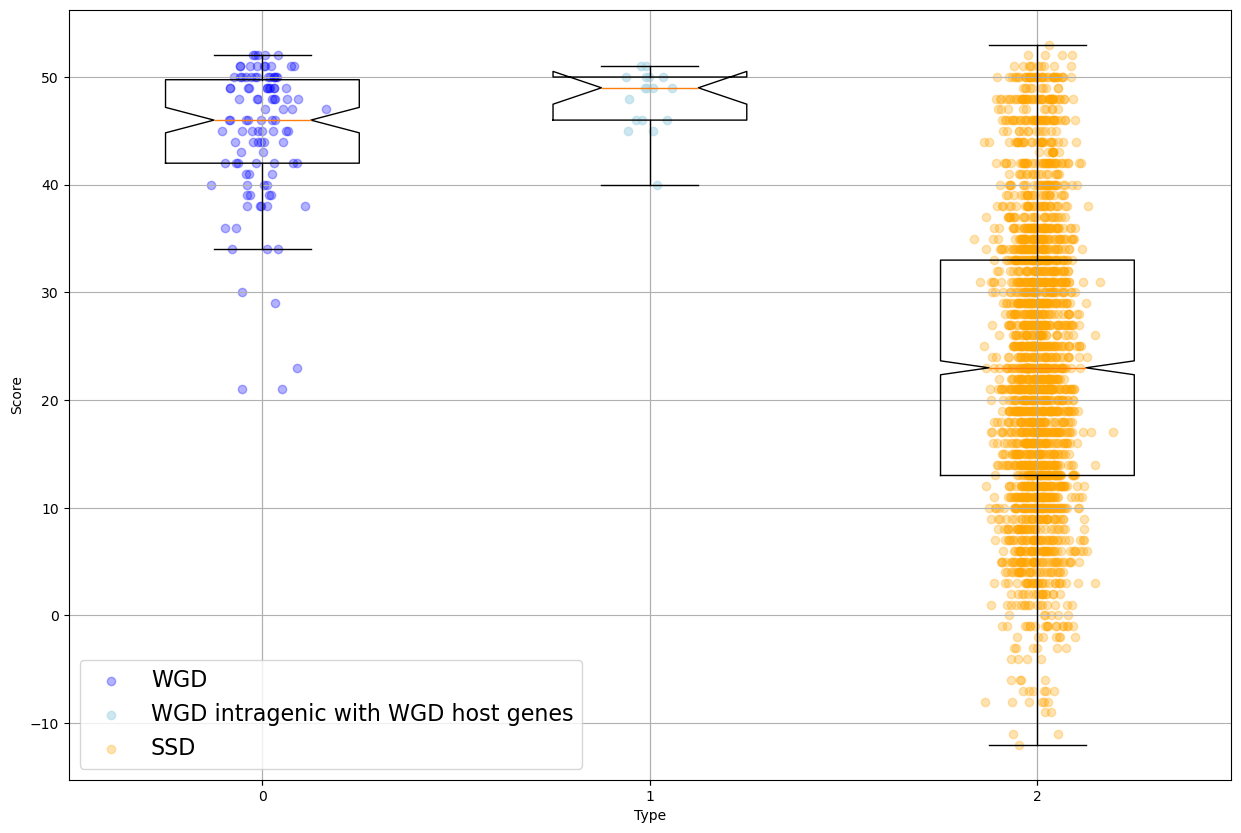

In [68]:
plt.figure(figsize=(15, 10))
plt.xlabel('Type')
plt.ylabel('Score')
plt.xticks([0, 1, 2], ['WGD', 'WGD intragenic with WGD host genes', 'SSD'])
plt.boxplot([df_wgd_scores, df_wgd_intragenic_scores, df_ssd_scores], positions=[0, 1, 2], widths=0.5, notch=True, showfliers=False)
plt.scatter(np.random.normal(0, 0.05, size=len(df_wgd_scores)), df_wgd_scores, alpha=0.3, color='blue', label='WGD')
plt.scatter(np.random.normal(1, 0.05, size=len(df_wgd_intragenic_scores)), df_wgd_intragenic_scores, alpha=0.6, color='lightblue', label='WGD intragenic with WGD host genes')
plt.scatter(np.random.normal(2, 0.05, size=len(df_ssd_scores)), df_ssd_scores, alpha=0.3, color='orange', label='SSD')
plt.legend(fontsize=16, loc='lower left')
plt.grid()
plt.show()

In [69]:
print(f'Number of WGD pairs: {len(df_wgd_scores)}')
print(f'Number of WGD intragenic pairs: {len(df_wgd_intragenic_scores)}')
print(f'Number of SSD pairs: {len(df_ssd_scores)}')

Number of WGD pairs: 106
Number of WGD intragenic pairs: 17
Number of SSD pairs: 2361
